In [9]:
import matplotlib.pyplot as plt
import numpy as np
import scipy as sp
import pandas as pd
import os
import gc
import sys

sys.path.insert(0, '..')
from src import *

# Test convergence speed against save frequency and time

## Timestep 0.005, steps 200k

In [ ]:
path = Filepaths.DATA.value / 'test'
save_every_arr = [100,30,10,3,1]
time_arr = ["1:12", "1:44", "3:17", "8:36", "23:52"]
corr3_arr = []

def stress3_term(stress, V, T, ind=(0,0,0,0,0,0)):
    i,j,k,l,m,n = ind
    return V**2 / (2*T**2) * (stress[:,i,j] * stress[:,k,l] * stress[:,m,n])

for save_every in save_every_arr:
    data = Data(path / f'save{save_every}')
    dataset = data.read(['thermo', 'press', 'press_pot', 'born'])
    thermo_data, press_data, press_pot_data, born_data = dataset.values()
    
    stress = -lammps_array_to_matrix(press_data.iloc[:,2:])
    stress_d = stress - stress.mean(axis=0)
    press_avg = -np.trace(stress.mean(axis=0)) / 3

    V = thermo_data.vol.mean()
    T = thermo_data.temp.mean()
    N_qs_corr3 = np.zeros((3,)*6)

    for i in range(3):
        for j in range(3):
            for k in range(3):
                for l in range(3):
                    for m in range(3):
                        for n in range(3):
                            _ind = i,j,k,l,m,n
                            N_qs_corr3[*_ind] = stress3_term(stress_d, V, T, _ind).mean(0)
    corr3_arr += [N_qs_corr3]

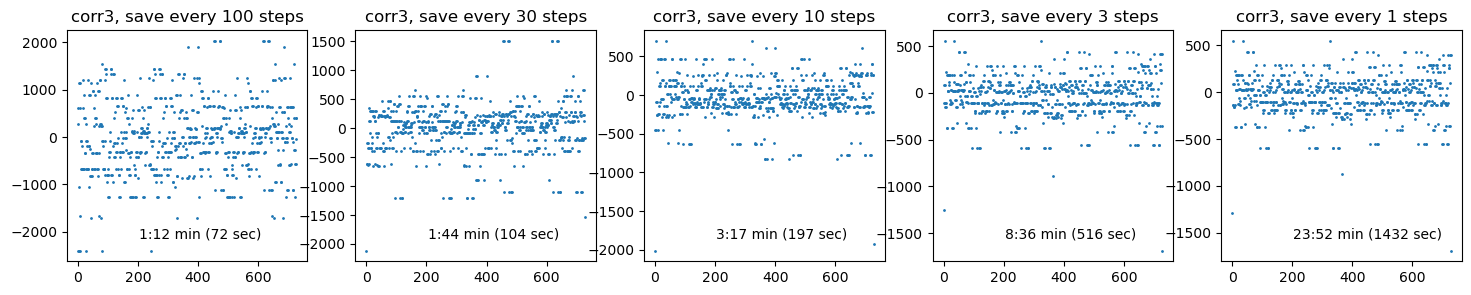

In [37]:
fig, axes = plt.subplots(1,len(save_every_arr), figsize=(18,3))
for ax, corr3, save_every, time in zip(axes, corr3_arr, save_every_arr, time_arr):
    ax.plot(corr3.flatten(), '.', ms=2)
    ax.set_title(f'corr3, save every {save_every} steps')
    time_s = np.array([int(time.split(':')[i]) for i in range(2)]) @ np.array([60, 1])
    ax.text(0.3, 0.1, f'{time} min ({time_s} sec)', transform=ax.transAxes)

## Timestep 0.002, steps 200k

In [3]:
path = Filepaths.DATA.value / 'test'
save_every_arr = [100,30,10,3,1]
time_arr  = []
corr3_arr = []

def stress3_term(stress, V, T, ind=(0,0,0,0,0,0)):
    i,j,k,l,m,n = ind
    return V**2 / (2*T**2) * (stress[:,i,j] * stress[:,k,l] * stress[:,m,n])

for save_every in save_every_arr:
    data = Data(path / f'save{save_every}_dt0.002')
    dataset = data.read(['thermo', 'press', 'press_pot', 'born'])
    thermo_data, press_data, press_pot_data, born_data = dataset.values()
    
    stress = -lammps_array_to_matrix(press_data.iloc[:,2:])
    stress_d = stress - stress.mean(axis=0)
    press_avg = -np.trace(stress.mean(axis=0)) / 3

    V = thermo_data.vol.mean()
    T = thermo_data.temp.mean()
    N_qs_corr3 = np.zeros((3,)*6)

    for i in range(3):
        for j in range(3):
            for k in range(3):
                for l in range(3):
                    for m in range(3):
                        for n in range(3):
                            _ind = i,j,k,l,m,n
                            N_qs_corr3[*_ind] = stress3_term(stress_d, V, T, _ind).mean(0)
    corr3_arr += [N_qs_corr3]
    time_arr += [data.get_wall_time()]

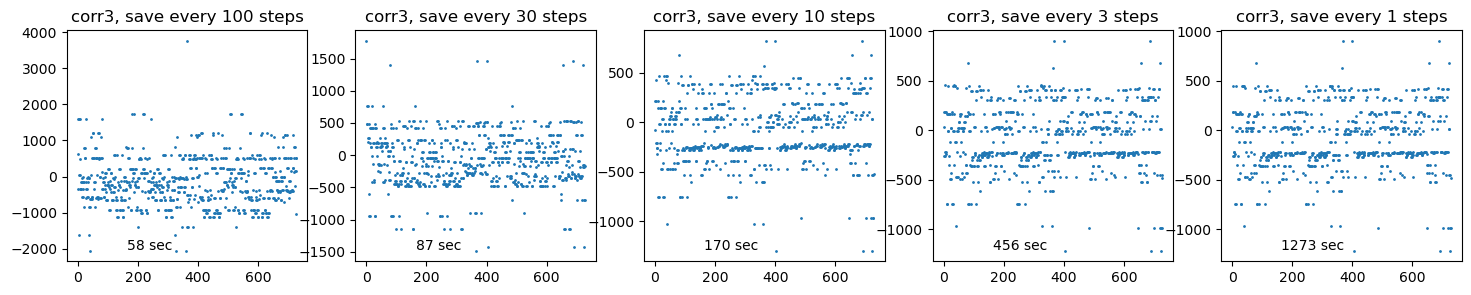

In [5]:
fig, axes = plt.subplots(1,len(save_every_arr), figsize=(18,3))
for ax, corr3, save_every, time in zip(axes, corr3_arr, save_every_arr, time_arr):
    ax.plot(corr3.flatten(), '.', ms=2)
    ax.set_title(f'corr3, save every {save_every} steps')
    ax.text(0.25, 0.05, f'{time} sec', transform=ax.transAxes)

## Timestep 0.002, steps 500k

In [10]:
path = Filepaths.DATA.value / 'test'
save_every_arr = [100,30,10,3]
time_arr  = []
corr3_arr = []

def stress3_term(stress, V, T, ind=(0,0,0,0,0,0)):
    i,j,k,l,m,n = ind
    return V**2 / (2*T**2) * (stress[:,i,j] * stress[:,k,l] * stress[:,m,n])

for save_every in save_every_arr:
    data = Data(path / f'save{save_every}_dt0.002')
    dataset = data.read(['thermo', 'press', 'press_pot', 'born'])
    thermo_data, press_data, press_pot_data, born_data = dataset.values()
    
    stress = -lammps_array_to_matrix(press_data.iloc[:,2:])
    stress_d = stress - stress.mean(axis=0)
    press_avg = -np.trace(stress.mean(axis=0)) / 3

    V = thermo_data.vol.mean()
    T = thermo_data.temp.mean()
    N_qs_corr3 = np.zeros((3,)*6)

    for i in range(3):
        for j in range(3):
            for k in range(3):
                for l in range(3):
                    for m in range(3):
                        for n in range(3):
                            _ind = i,j,k,l,m,n
                            N_qs_corr3[*_ind] = stress3_term(stress_d, V, T, _ind).mean(0)
    corr3_arr += [N_qs_corr3]
    time_arr += [data.get_wall_time()]

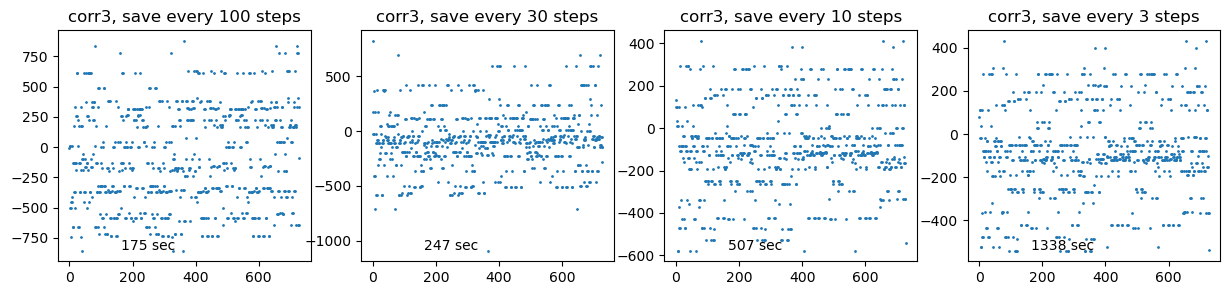

In [11]:
fig, axes = plt.subplots(1,len(save_every_arr), figsize=(15,3))
for ax, corr3, save_every, time in zip(axes, corr3_arr, save_every_arr, time_arr):
    ax.plot(corr3.flatten(), '.', ms=2)
    ax.set_title(f'corr3, save every {save_every} steps')
    ax.text(0.25, 0.05, f'{time} sec', transform=ax.transAxes)